You need to install first MGCLASS II from  "https://gitlab.com/zizgitlab/mgclass--ii"

In [ ]:
# General imports
import numpy as np
import matplotlib.pyplot as plt

# cloelite imports: we load the following interfaces
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.cosmology.mgclass_cosmology import CLASSBackground as MGCLASSBackground
from cloelib.cosmology.mgclass_cosmology import CLASSLinearPerturbations as MGCLASSLinearPerturbations, CLASSNonLinearPerturbations as MGCLASSNonLinearPerturbations 
from cloelib.cosmology.class_cosmology import CLASSBackground, CLASSLinearPerturbations, CLASSNonLinearPerturbations 
from cloelib.cosmology.cosmology import Background

# Background quantities

In [18]:
# Cosmology parameters
H0 =  67.7
h = H0/100.
sigma8 = 0.8277
omch2 = 0.12
Omega_cdm0 = omch2/h**2
ombh2 = 0.022
Omega_b0 = ombh2/h**2
Omega_k0 = 0.
w = -1.
wa = 0.
ns = 0.96
mnu = 0.
As=2e-9
N_mnu=0

# z-array
z = np.linspace(0, 3, 100)

camb_instance = CAMBBackground(H0=H0, Omega_b0=Omega_b0, Omega_cdm0=Omega_cdm0, 
                               Omega_k0=Omega_k0,
                               As=As, ns=ns, mnu=mnu, w0=w, wa=wa, 
                               gamma_MG=0.0, N_mnu=N_mnu)


mgclass_instance = MGCLASSBackground(H0=H0, Omega_b0=Omega_b0, Omega_cdm0=Omega_cdm0, 
                               Omega_k0=Omega_k0,
                               As=As, ns=ns, mnu=mnu, w0=w, wa=wa, 
                               gamma_MG=0.0, mg_ansatz='plk_musigma_norm_late', mg_z_init=6.0,
                               mg_params={'mg_E11':0.5, 'mg_E22':0.5}, N_mnu=N_mnu)

mgclass_lcdm_instance = MGCLASSBackground(H0=H0, Omega_b0=Omega_b0, Omega_cdm0=Omega_cdm0, 
                               Omega_k0=Omega_k0,
                               As=As, ns=ns, mnu=mnu, w0=w, wa=wa, 
                               gamma_MG=0.0, mg_ansatz='plk_musigma_norm_late', mg_z_init=0.0,
                               mg_params={'mg_E11':0.0, 'mg_E22':0.0}, N_mnu=N_mnu)

class_lcdm_instance = CLASSBackground(H0=H0, Omega_b0=Omega_b0, Omega_cdm0=Omega_cdm0, 
                               Omega_k0=Omega_k0,
                               As=As, ns=ns, mnu=mnu, w0=w, wa=wa, 
                               gamma_MG=0.0, N_mnu=N_mnu)

## Check MGClass Background

In [5]:
H_z_camb = camb_instance.hubble_parameter(z, units='km/s/Mpc')
chi_z_camb = camb_instance.comoving_distance(z)
dA_z_camb = camb_instance.angular_diameter_distance(z)
tr_z_camb = camb_instance.transverse_comoving_distance(z)

H_z_mgclass = mgclass_instance.hubble_parameter(z)
chi_z_mgclass = mgclass_instance.comoving_distance(z)
dA_z_mgclass = mgclass_instance.angular_diameter_distance(z)
tr_z_mgclass = mgclass_instance.transverse_comoving_distance(z)

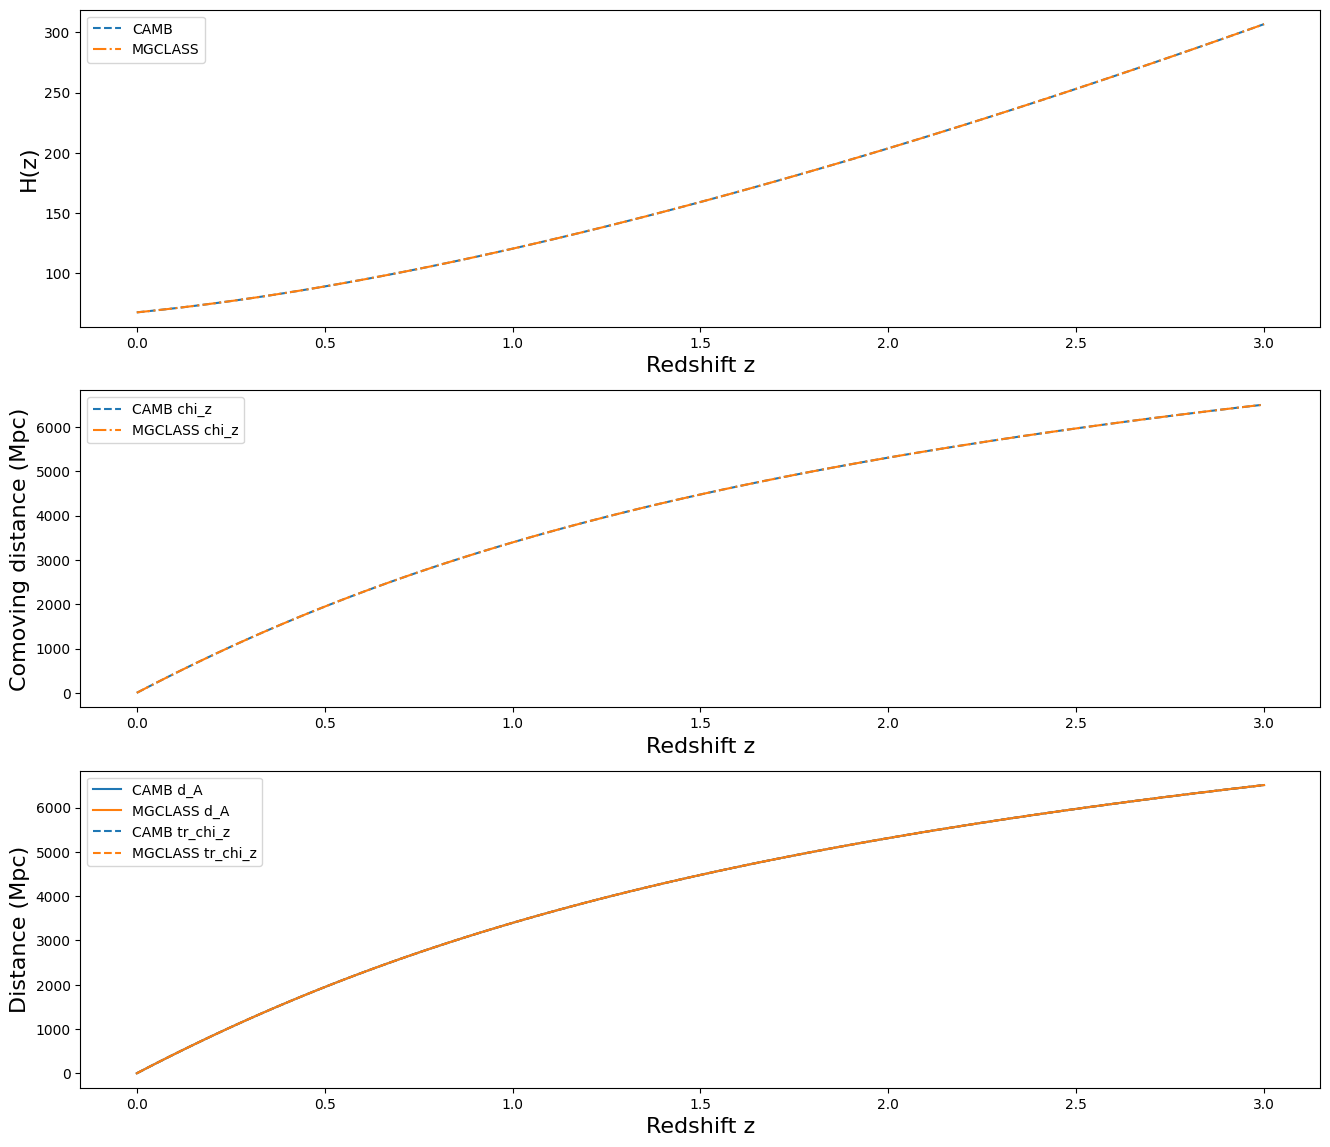

In [6]:
fig, axs = plt.subplots(figsize = (16,14), nrows=3, ncols=1)
axs[0].plot(z, H_z_camb, label = 'CAMB', ls='--')
axs[0].plot(z, H_z_mgclass, label = 'MGCLASS', ls='-.')
axs[0].set_ylabel('H(z)', fontsize = 16)
axs[0].set_xlabel('Redshift z', fontsize = 16)
axs[0].legend()
axs[1].plot(z, chi_z_camb, label = 'CAMB chi_z', ls='--')
axs[1].plot(z, chi_z_mgclass, label = 'MGCLASS chi_z', ls='-.')
axs[1].set_ylabel('Comoving distance (Mpc)', fontsize = 16)
axs[1].set_xlabel('Redshift z', fontsize = 16)
axs[1].legend()
axs[2].plot(z, dA_z_camb*(1+z), label = 'CAMB d_A', ls='-')
axs[2].plot(z, dA_z_mgclass*(1+z), label = 'MGCLASS d_A', ls='-')
axs[2].set_ylabel('Distance (Mpc)', fontsize = 16)
plt.gca().set_prop_cycle(None)
axs[2].plot(z, tr_z_camb, label = 'CAMB tr_chi_z', ls='--')
axs[2].plot(z, tr_z_mgclass, label = 'MGCLASS tr_chi_z', ls='--')
axs[2].set_xlabel('Redshift z', fontsize = 16)
axs[2].legend()

## Check if Cosmology Classes are part of Background protocol

In [ ]:
import os
import sys

# Add the parent of parent directory (playground) to Python path
# Add the protocols_test directory to Python path
protocols_test_dir = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), 'protocols_test')
sys.path.append(protocols_test_dir)

# Now import from protocols_test
from compliance import check_protocol_compliance
check_protocol_compliance(mgclass_instance, Background, verbose=False)
check_protocol_compliance(camb_instance, Background, verbose=False)

## Check MGClass perturbations

In [8]:
# CAMB PERTURBATIONS
camb_linear = CAMBLinearPerturbations(background=camb_instance, redshifts=z)
camb_nonlinear = CAMBNonLinearPerturbations(background=camb_instance, redshifts=z, 
                                            nonlinear_model='mead2016')

Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)


In [19]:
# CLASS PERTURBATIONS
mgclass_linear = MGCLASSLinearPerturbations(background=mgclass_instance, redshifts=z)
mgclass_lcdm_linear = MGCLASSLinearPerturbations(background=mgclass_lcdm_instance, redshifts=z)
class_lcdm_linear = CLASSLinearPerturbations(background=class_lcdm_instance, redshifts=z)
mgclass_nonlinear = MGCLASSNonLinearPerturbations(background=mgclass_instance, 
                                              redshifts=z, 
                                              nonlinear_model='hmcode16')

In [10]:
ks = np.logspace(np.log10(1e-4), np.log10(5), 100)

In [11]:
linear_pk_camb = camb_linear.matter_power_spectrum(z, ks)
nonlinear_pk_camb = camb_nonlinear.matter_power_spectrum(z, ks)

In [20]:
linear_pk_mgclass = mgclass_linear.matter_power_spectrum(z, ks)
linear_pk_mgclass_lcdm = mgclass_lcdm_linear.matter_power_spectrum(z, ks)
nonlinear_pk_mgclass = mgclass_nonlinear.matter_power_spectrum(z, ks)
linear_pk_class_lcdm = class_lcdm_linear.matter_power_spectrum(z, ks)

Text(0.5, 1.0, 'MGCLASS Perturbations')

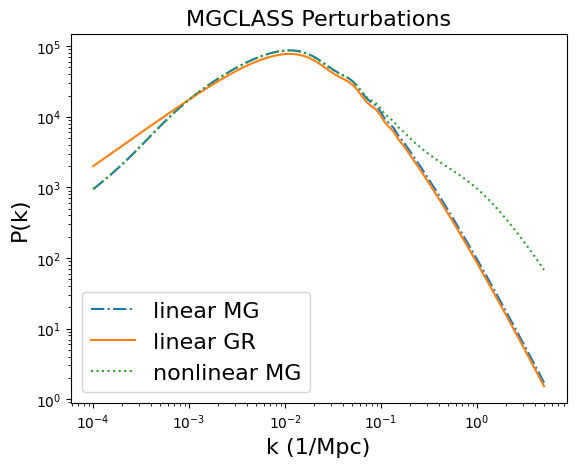

In [21]:
plt.loglog(ks, linear_pk_mgclass[0, :], label= 'linear MG',ls='-.')
plt.loglog(ks, linear_pk_class_lcdm[0, :], label= 'linear GR')
plt.loglog(ks, nonlinear_pk_mgclass[0, :], label= 'nonlinear MG',ls=':')
plt.xlabel('k (1/Mpc)', fontsize = 16)
plt.ylabel('P(k)', fontsize = 16)
plt.legend(fontsize = 16)
plt.title("MGCLASS Perturbations", fontsize = 16)

Text(0.5, 1.0, 'Pk compare, z = 1.5')

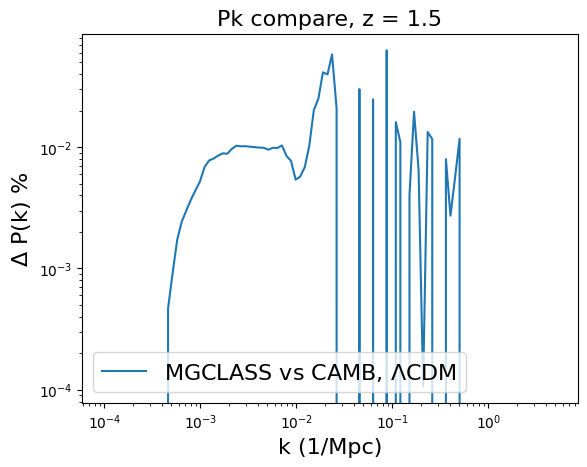

In [30]:
plt.loglog(ks, (linear_pk_camb[50, :]-linear_pk_mgclass_lcdm[50, :])/linear_pk_camb[50, :]*100.0, label= 'MGCLASS vs CAMB, $\Lambda$CDM')
plt.xlabel('k (1/Mpc)', fontsize = 16)
plt.ylabel('$\Delta$ P(k) %', fontsize = 16)
plt.legend(fontsize = 16)
plt.title("Pk compare, z = 1.5", fontsize = 16)

# differences are the same as between plain CLASS and CAMB

Text(0.5, 1.0, 'CAMB vs. MGCLASS Linear Perturbations')

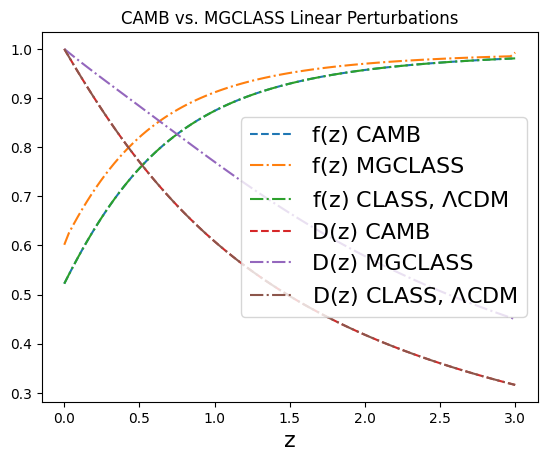

In [29]:
#calculate results for these parameters
plt.plot(z, camb_linear.growth_rate(), label = 'f(z) CAMB', ls='--')
plt.plot(z, mgclass_linear.growth_rate(), label = 'f(z) MGCLASS', ls='-.')
plt.plot(z, class_lcdm_linear.growth_rate(), label = 'f(z) CLASS, $\Lambda$CDM', ls='-.')
plt.plot(z, camb_linear.growth_factor(z,ks)[:, 0], label = 'D(z) CAMB', ls='--')
plt.plot(z, mgclass_linear.growth_factor(z,ks)[:, 0], label = 'D(z) MGCLASS', ls='-.')
plt.plot(z, class_lcdm_linear.growth_factor(z,ks)[:, 0], label = 'D(z) CLASS, $\Lambda$CDM', ls='-.')
plt.xlabel('z', fontsize = 16)
plt.legend(fontsize = 16)
plt.title("CAMB vs. MGCLASS Linear Perturbations")